# DePSI example workflow


In this notebook, we will demonstrate an example workflow of using DePSI to derive deformation products from Sentinel-1 SLC data.

Data used in this example: [download link](https://figshare.com/ndownloader/files/54495791).

In [1]:
import numpy as np
import xarray as xr

from matplotlib import pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as plc

from depsi.io import read_slc_stack
from depsi.classification import ps_selection, network_stm_selection
from depsi.point_quality import detect_outliers_stm, stm_partitioning, stm_add_incremental_recal_nad_nmad, detect_side_lobes
from depsi.network import stm_to_arcs

## Load the Zarr format SLC stack

In this notebook, we will use a cropped and geocoded SLC stack `nl_amsterdam_extended_s1_asc_t088.zarr`. It also contains the following information:
- `real` and `imag`: the real and imaginary parts of the complex SLC data.
- `azimuth` and `range`: radar coordinates in the original SLC framework before cropping.
- `h2ph`: the phase to height ratio.
- `lat` and `lon`: WGS84 pixel coordinates.

We load the Zarr stack using the `read_slc_stack` function from DePSI. This function returns an Xarray.Dataset object. It reads most of the existing variables in Zarr. However intead of reading `real` and `imag` directly, it creates the following three variables as Dask arrays:
- `complex`: complex values derived from the real and imaginary parts.
- `amplitude`: amplitude derived from the complex values.
- `phase`: phase derived from the complex values.

In this way, we can avoid loading data into memory that we do not need, but still have access to the fields which are relevant for PSI processing. 

For more explaination of this behavior, please refer to the [user documentation](https://tudelftgeodesy.github.io/DePSI_group/usages/slc/) of `read_slc_stack`.

In [2]:
slcs = read_slc_stack('../../../data/nl_amsterdam_extended_s1_asc_t088.zarr')

## PS point selection

We will use the `ps_point_selection` function to select Persistance Scatterers (PS) from the SLC stack. In this example, we use the Normalized Median Amplitude Dispersion (NMAD) as the selection criterion.

Please note that this step will covert a raster SLC stack into an Space-Time Matrix, i.e. change the data dimension from (azimuth, range, time) to (space, time). Therefore, although by `mem_persist=False` we can avoid loading all variables in Zarr into memory, the complex data related variables will be loaded to compute the NMAD, which is required to create the mask for PS selection.

The output will be an Xarray.Dataset with selected PS. The other pixels will be dropped. 

In [3]:
stm = ps_selection(slcs,
                   method="nmad",
                   threshold=0.30,
                   output_chunks=1000,
                   mem_persist=False)             

## STM quality control (Optional)

After the PS selection, we can optionaly perform algorithms to improve the quality of the STM. The module `depsi.point_quality` provides various functions to perform quality control on STM. In this example we will demonstrate the `detect_outliers_stm` function, which detects outliers of each space instance in the STM, by applying a hampel filter. It will append a new data variable `outliers` to the input STM. `outliers` is a boolean variable with True indicating an outlier detected for that point at that epoch.

For more quality control functions, please refer to the [user documentation](https://tudelftgeodesy.github.io/DePSI_group/usages/quality/) of `depsi.point_quality`.


In [4]:
# Outlier detection
stm = detect_outliers_stm(stm)

## Network unwrapping

In the next stage, we will form a network of PS points and perform network unwrapping to resolve the phase ambiguities. This stage contains the following steps:
1. select network STM
2. arc formation: form network arcs between the selected PS points
3. arc unwrapping: unwrap the phases of the arcs
4. network integration: solve the network STM phases from the unwrapped arcs

In this example, we demonstrate an example network unwrapping workflow. For the details of all network related functions, please refer to the [user documentation](https://tudelftgeodesy.github.io/DePSI_group/usages/network/) of `depsi.network`.

### Network point selection

In [5]:
stm_network = network_stm_selection(stm, min_dist=200, azimuth_spacing=20, range_spacing=5)

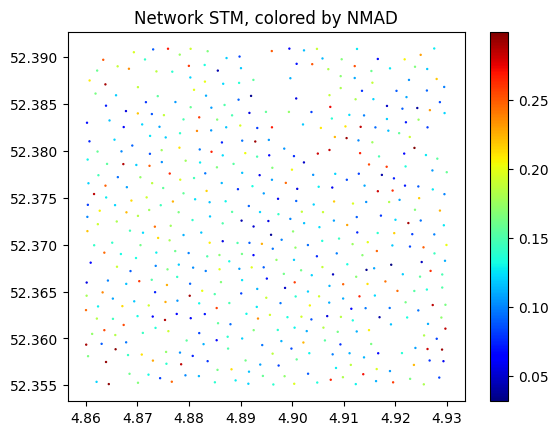

In [6]:
# Visualize results
colormap = cm.jet
fig, ax = plt.subplots()
plt.title("Network STM, colored by NMAD")
plt.scatter(stm_network['lon'], stm_network['lat'], c=stm_network['time_selection_nmad'], s=0.5, cmap=colormap)
plt.colorbar()

### Network arc generation

In [7]:
stm_network_arcs = stm_to_arcs(stm_network, network="redundant", max_length=0.004, difference="subtract")

Text(0.5, 1.0, 'Network STM arcs, colored by average NMAD')

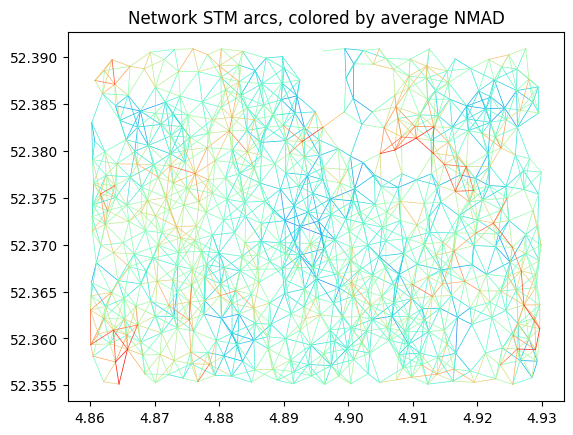

In [8]:
# x of sources and targets
xx = np.stack([stm_network.isel(space = stm_network_arcs['source'])['lon'].values,
               stm_network.isel(space = stm_network_arcs['target'])['lon'].values]).T
# y of sources and targets
yy = np.stack([stm_network.isel(space = stm_network_arcs['source'])['lat'].values,
               stm_network.isel(space = stm_network_arcs['target'])['lat'].values]).T
# Visualize created arcs
fig, ax = plt.subplots()
cmap = plt.cm.rainbow
norm = plc.Normalize(vmin=0, vmax=0.3)
mean_nmad = (stm_network.isel(space = stm_network_arcs['source'])['time_selection_nmad'].values + stm_network.isel(space = stm_network_arcs['target'])['time_selection_nmad'].values)/2
for i in range(stm_network_arcs.sizes["space"]):
    ax.plot(xx[i], yy[i], color=cmap(norm(mean_nmad[i])), linewidth=0.5)
plt.title("Network STM arcs, colored by average NMAD")

### Arc unwrapping

In [9]:
# TODO: implement periodogram unwrapping and add it here

### Network integration